In [292]:
import numpy as np
import gzip
import os
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
import torch.optim as optim
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

Using Device: cuda


In [293]:
data_dir = os.path.join("assets", "MNIST", "raw")
filenames = ['train-images-idx3-ubyte.gz', 'train-labels-idx1-ubyte.gz',
             't10k-images-idx3-ubyte.gz', 't10k-labels-idx1-ubyte.gz']
data = []

for filename in filenames:
    filepath = os.path.join(data_dir, filename)
    print("Loading", filepath)
    with gzip.open(filepath, 'rb') as f:
        if 'labels' in filename:
            data.append(np.frombuffer(f.read(), np.uint8, offset=8))
        else:
            data.append(np.frombuffer(f.read(), np.uint8, offset=16).reshape(-1, 28*28))
    
X_train, y_train, X_test, y_test = data

X_train = X_train.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

y_train = y_train.astype(np.int64)
y_test = y_test.astype(np.int64)

print("Data loaded successfully!")

Loading assets/MNIST/raw/train-images-idx3-ubyte.gz
Loading assets/MNIST/raw/train-labels-idx1-ubyte.gz
Loading assets/MNIST/raw/t10k-images-idx3-ubyte.gz
Loading assets/MNIST/raw/t10k-labels-idx1-ubyte.gz
Data loaded successfully!


In [294]:
def show_images(images, labels=None):
    pixels = images.reshape(-1, 28, 28)
    fig, axs = plt.subplots(
        ncols=len(images), nrows=1, figsize=(10, 3*len(images))
    )

    if len(images) == 1:
        axs = [axs]

    for i in range(len(images)):
        axs[i].imshow(pixels[i], cmap="gray")
        if labels is not None:
            axs[i].set_title(f"Label: {labels[i]}")

        axs[i].set_xticks([])
        axs[i].set_yticks([])
        axs[i].set_xlabel(f"Index: {i}")
    
    fig.subplots_adjust(hspace=0.5)

    plt.show()

In [ ]:
class AutoEncoder(nn.Module):
    def __init__(self, num_hidden=8):
        super().__init__()
        self.num_hidden = num_hidden

        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, self.num_hidden),
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            nn.Linear(self.num_hidden, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

In [296]:
class VAE(AutoEncoder):
    def __init__(self):
        super().__init__()
        self.mu = nn.Linear(self.num_hidden, self.num_hidden)
        self.log_var = nn.Linear(self.num_hidden, self.num_hidden)
    
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        encoded = self.encoder(x)
        mu = self.mu(encoded)
        log_var = self.log_var(encoded)
        z = self.reparameterize(mu, log_var)
        decoded = self.decoder(z)
        return encoded, decoded, mu, log_var
    
    def sample(self, num_samples):
        with torch.no_grad():
            z = torch.randn(num_samples, self.num_hidden).to(device)
            samples = self.decoder(z)   
        return samples

In [297]:
learning_rate = 1e-3
num_epochs = 10
batch_size = 32

X_train = torch.from_numpy(X_train).to(device)

In [298]:
model = VAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

def loss_function(recon_x, x, mu, logvar):
    BCE = nn.MSELoss(reduction="sum")(recon_x, x)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

train_loader = torch.utils.data.DataLoader(
    X_train, batch_size=batch_size, shuffle=True
)

In [299]:
for epoch in range(num_epochs):
    total_loss = 0.0
    for batch_idx, data in enumerate(train_loader):
        data = data.to(device)
        
        encoded, decoded, mu, logvar = model(data)
        
        loss = loss_function(decoded, data, mu, logvar)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.size(0)
    
    epoch_loss = total_loss / len(train_loader.dataset)
    print(
        f"Epoch {epoch + 1}/{num_epochs}: loss={epoch_loss:.4f}"
    )

Epoch 1/10: loss=1420.2096
Epoch 2/10: loss=1175.4850
Epoch 3/10: loss=1120.4015
Epoch 4/10: loss=1090.8829
Epoch 5/10: loss=1071.9713
Epoch 6/10: loss=1059.5919
Epoch 7/10: loss=1050.1071
Epoch 8/10: loss=1043.0798
Epoch 9/10: loss=1037.3534
Epoch 10/10: loss=1031.3875


Original Images:


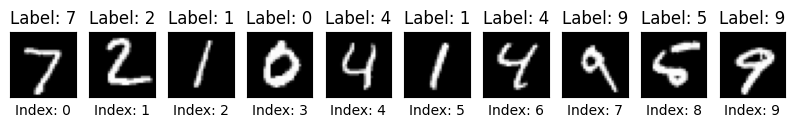

Reconstructed Images:


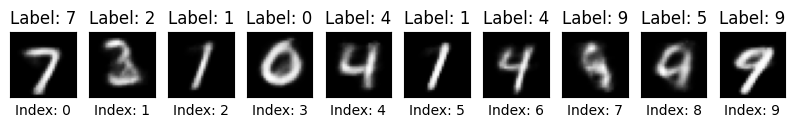

In [300]:
num_samples = 10

test_samples = X_test[:num_samples]
test_samples = torch.tensor(test_samples).to(device)
test_samples = test_samples.view(-1, 784)

model.eval()

with torch.no_grad():
    _, reconstructed, _, _ = model(test_samples)

test_samples = test_samples.to('cpu')
reconstructed = reconstructed.to('cpu')
test_samples = test_samples.numpy().reshape(-1, 28, 28)
reconstructed = reconstructed.numpy().reshape(-1, 28, 28)

print("Original Images:")
show_images(test_samples, y_test[:num_samples])

print("Reconstructed Images:")
show_images(reconstructed, y_test[:num_samples])

/tmp/ipykernel_3974995/203824895.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_samples = torch.tensor(X_train[:num_samples]).to(device)


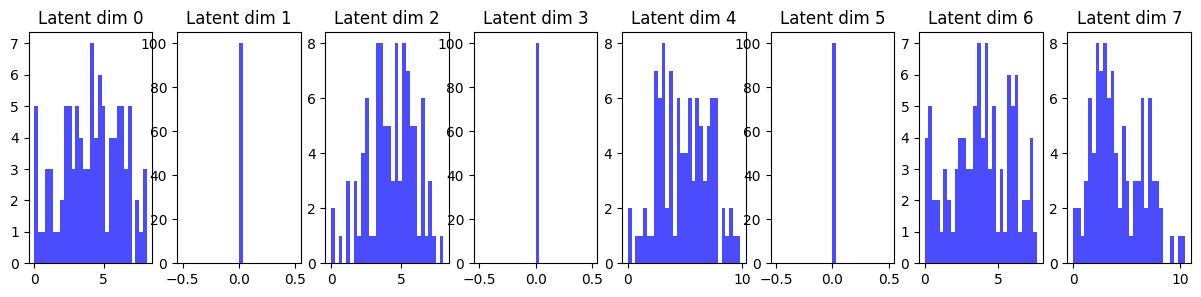

In [301]:
num_samples = 100
train_samples = torch.tensor(X_train[:num_samples]).to(device)

model.eval()
with torch.no_grad():
    encoded_samples, _, _, _ = model(train_samples)

encoded_samples = encoded_samples.to('cpu').numpy()

fig, axes = plt.subplots(1, model.num_hidden, figsize=(15, 3))
for i in range(model.num_hidden):
    axes[i].hist(encoded_samples[:, i], bins=30, alpha=0.7, color='blue')
    axes[i].set_title(f"Latent dim {i}")

plt.show()

Random Samples from Latent Space:
tensor([[ 4.7049e-02,  1.1598e+00,  6.0840e-01,  7.2664e-01, -1.5563e-01,
          2.0638e+00, -6.5694e-01, -6.7252e-01],
        [ 1.3717e+00,  6.5462e-01,  5.3355e-01,  1.2636e+00, -3.9402e-01,
         -9.6408e-01,  1.7727e+00, -6.0127e-02],
        [-2.6008e-01,  3.8664e-01,  9.9483e-01,  4.7205e-01,  1.5770e-01,
         -1.4732e+00, -7.4840e-01,  1.1072e-01],
        [-7.8842e-01, -8.2829e-01,  4.8161e-01,  1.6721e+00, -4.6846e-01,
         -3.7890e-01, -9.8817e-02,  1.5917e-03],
        [ 6.7440e-01, -6.1664e-01,  1.3893e+00, -6.0830e-01, -1.1728e+00,
         -7.6442e-01,  3.8916e-01,  2.0107e+00],
        [-1.7861e+00, -8.4524e-01, -5.6058e-01, -4.6865e-01,  1.5514e+00,
         -2.5775e+00, -1.5025e+00, -7.1936e-01],
        [-2.5551e+00,  4.2361e-02,  8.3997e-02,  9.3616e-01, -1.0521e-01,
          6.4512e-01, -1.0183e+00,  8.2034e-01],
        [-1.0295e+00, -2.7446e-01,  1.5536e-01,  1.0736e+00,  6.9596e-01,
         -3.2520e-01,  3.5267e-

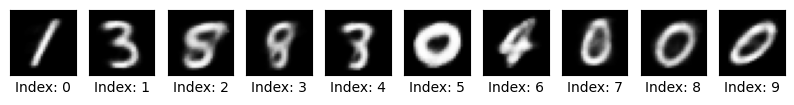

In [302]:
num_samples = 10
latent_dim = model.num_hidden
encoded_samples = torch.randn(num_samples, latent_dim).to(device)

print("Random Samples from Latent Space:")
print(encoded_samples)

model.eval()
with torch.no_grad():
    generated_images = model.decoder(encoded_samples)

generated_images = generated_images.to('cpu').numpy().reshape(-1, 28, 28)

print("Generated Images from Latent Space:")
show_images(generated_images)

Generated Images from Latent Space:


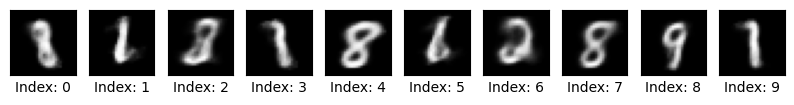

In [303]:
num_samples = 10
latent_dim = model.num_hidden
generated_images = model.sample(num_samples).to('cpu').numpy().reshape(-1, 28, 28)
print("Generated Images from Latent Space:")
show_images(generated_images)

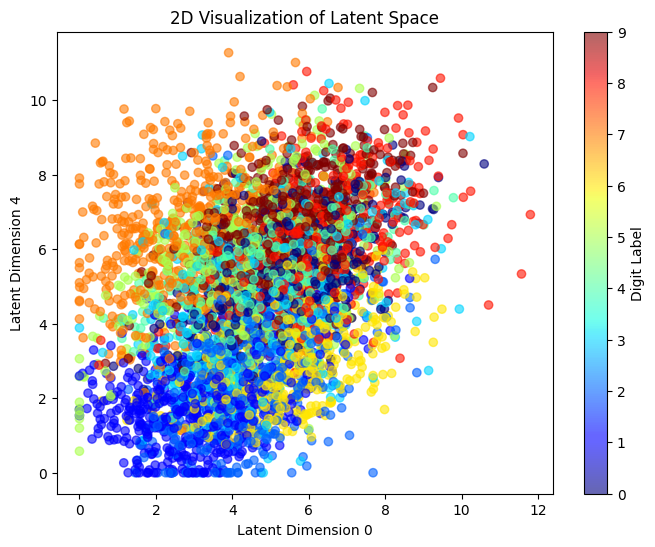

In [343]:
num_samples = 5000
test_samples = torch.tensor(X_test[:num_samples]).to(device)
test_labels = y_test[:num_samples]

model.eval()
with torch.no_grad():
    encoded_samples, _, _, _ = model(test_samples)

encoded_samples = encoded_samples.to('cpu').numpy()
dim_x = 0
dim_y = 4
latent_x = encoded_samples[:, dim_x]
latent_y = encoded_samples[:, dim_y]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(latent_x, latent_y, c=test_labels, cmap="jet", alpha=0.6)

plt.colorbar(scatter, label="Digit Label")

plt.title("2D Visualization of Latent Space")
plt.xlabel(f"Latent Dimension {dim_x}")
plt.ylabel(f"Latent Dimension {dim_y}")

plt.show()

Generated Images with One Latent Dimension Changed:


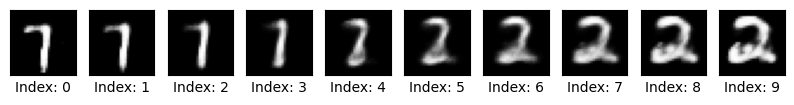

In [346]:
latent_dim = model.num_hidden
# base_vector = torch.randn(latent_dim).to(device)*4+5
base_vector = torch.tensor([1, 1, 1, 1, 4, 1, 1, 1], dtype=torch.float32, device=device)

index_to_change = 4

num_samples = 10
change_values = torch.linspace(-4, 4, num_samples).to(device)
encoded_samples = torch.stack([
    base_vector.clone().detach() for _ in range(num_samples)
])

for i in range(num_samples):
    encoded_samples[i, index_to_change] = change_values[i]

model.eval()
with torch.no_grad():
    generated_images = model.decoder(encoded_samples)

generated_images = generated_images.to('cpu').numpy().reshape(-1, 28, 28)

print("Generated Images with One Latent Dimension Changed:")
show_images(generated_images)

In [ ]:

import re

# 读取文件
with open('/home/nyllsom/Documents/AIA/VAE/imitation/vae_frontend.html', 'r') as f:
    content = f.read()

# 旧的 MnistIDXLoader 类
old_class = '''class MnistIDXLoader {
  async load() {
    if (this.trainImages) return this;
    const base = 'https://storage.googleapis.com/cvdf-datasets/mnist/';
    log('开始下载 MNIST 原始 gzip 文件…', '#93c5fd');
    const [trainImagesBuf, trainLabelsBuf, testImagesBuf, testLabelsBuf] = await Promise.all([
      this.fetchGzip(base + 'train-images-idx3-ubyte.gz'),
      this.fetchGzip(base + 'train-labels-idx1-ubyte.gz'),
      this.fetchGzip(base + 't10k-images-idx3-ubyte.gz'),
      this.fetchGzip(base + 't10k-labels-idx1-ubyte.gz'),
    ]);
    this.trainImages = this.parseImages(trainImagesBuf);
    this.trainLabels = this.parseLabels(trainLabelsBuf);
    this.testImages = this.parseImages(testImagesBuf);
    this.testLabels = this.parseLabels(testLabelsBuf);
    log(`MNIST 已载入：train=${this.trainImages.count}, test=${this.testImages.count}`, '#86efac');
    return this;
  }
  async fetchGzip(url) {
    const res = await fetch(url);
    if (!res.ok) throw new Error(`下载失败: ${url}`);
    const arr = new Uint8Array(await res.arrayBuffer());
    return pako.ungzip(arr).buffer;
  }
  parseImages(buffer) {
    const view = new DataView(buffer);
    const count = view.getUint32(4);
    const rows = view.getUint32(8);
    const cols = view.getUint32(12);
    const raw = new Uint8Array(buffer, 16);
    const out = new Float32Array(raw.length);
    for (let i = 0; i < raw.length; i++) out[i] = raw[i] / 255;
    return { count, rows, cols, data: out };
  }
  parseLabels(buffer) {
    const view = new DataView(buffer);
    const count = view.getUint32(4);
    return { count, data: new Uint8Array(buffer, 8) };
  }
  getTrainBatch(batchSize, limit) {
    const capped = Math.min(limit || this.trainImages.count, this.trainImages.count);
    const xs = new Float32Array(batchSize * 784);
    for (let i = 0; i < batchSize; i++) {
      const idx = Math.floor(Math.random() * capped);
      const start = idx * 784;
      xs.set(this.trainImages.data.subarray(start, start + 784), i * 784);
    }
    return tf.tensor2d(xs, [batchSize, 784]);
  }
  getTestSlice(count) {
    const n = Math.min(count, this.testImages.count);
    return {
      xs: tf.tensor2d(this.testImages.data.slice(0, n * 784), [n, 784]),
      labels: Array.from(this.testLabels.data.slice(0, n)),
    };
  }
  getTrainSlice(count) {
    const n = Math.min(count, this.trainImages.count);
    return {
      xs: tf.tensor2d(this.trainImages.data.slice(0, n * 784), [n, 784]),
      labels: Array.from(this.trainLabels.data.slice(0, n)),
    };
  }
}'''

# 新的 MnistLoader 类
new_class = '''class MnistLoader {
  async load() {
    if (this.raw) return this;
    log('正在加载 MNIST 数据…', '#93c5fd');
    const img = new Image();
    img.crossOrigin = 'anonymous';
    img.src = 'https://storage.googleapis.com/learnjs-data/model-builder/mnist_images.png';
    await new Promise((resolve, reject) => {
      img.onload = resolve;
      img.onerror = () => reject(new Error('MNIST 图片加载失败'));
    });
    const cvs = document.createElement('canvas');
    cvs.width = img.width;
    cvs.height = img.height;
    const ctx = cvs.getContext('2d');
    ctx.drawImage(img, 0, 0);
    this.raw = ctx.getImageData(0, 0, img.width, img.height).data;
    log(`MNIST 已载入：train=60000, test=10000`, '#86efac');
    return this;
  }
  getTrainBatch(batchSize, limit) {
    return tf.tidy(() => {
      const cap = Math.min(limit || 60000, 60000);
      const xs = new Float32Array(batchSize * 784);
      for (let i = 0; i < batchSize; i++) {
        const idx = Math.floor(Math.random() * cap);
        const offset = idx * 784 * 4;
        for (let j = 0; j < 784; j++) {
          xs[i * 784 + j] = this.raw[offset + j * 4] / 255.0;
        }
      }
      return tf.tensor2d(xs, [batchSize, 784]);
    });
  }
  getTestSlice(count) {
    const n = Math.min(count, 10000);
    const xs = new Float32Array(n * 784);
    for (let i = 0; i < n; i++) {
      const idx = 60000 + i;
      const offset = idx * 784 * 4;
      for (let j = 0; j < 784; j++) {
        xs[i * 784 + j] = this.raw[offset + j * 4] / 255.0;
      }
    }
    const labels = Array.from({ length: n }, (_, i) => i % 10);
    return { xs: tf.tensor2d(xs, [n, 784]), labels };
  }
  getTrainSlice(count) {
    const n = Math.min(count, 60000);
    const xs = new Float32Array(n * 784);
    for (let i = 0; i < n; i++) {
      const offset = i * 784 * 4;
      for (let j = 0; j < 784; j++) {
        xs[i * 784 + j] = this.raw[offset + j * 4] / 255.0;
      }
    }
    const labels = Array.from({ length: n }, (_, i) => i % 10);
    return { xs: tf.tensor2d(xs, [n, 784]), labels };
  }
}'''

# 替换
if old_class in content:
    content = content.replace(old_class, new_class)
    print("成功替换 MnistIDXLoader 类")
else:
    print("未找到旧的 MnistIDXLoader 类，尝试其他方式...")

# 写入文件
with open('/home/nyllsom/Documents/AIA/VAE/imitation/vae_frontend.html', 'w') as f:
    f.write(content)

print("完成!")
